In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import gc
import warnings
warnings.filterwarnings('ignore')

base_dir = Path(r"C:\Users\aabassetc2\Documents\github\benchmark-integration")
output_dir = base_dir / "data" / "output"

# Display order (this order is used everywhere: table, plots, UMAPs)
DISPLAY_ORDER = ["unintegrated", "scvi", "harmony", "cca", "rpca"]

# Methods config: maps display name → source h5ad file and obsm key
METHODS_CONFIG = {
    "unintegrated": {"h5ad": "unintegrated", "source_obsm": "X_pca"},
    "scvi":         {"h5ad": "scvi",         "source_obsm": "X_scvi"},
    "harmony":      {"h5ad": "harmony",      "source_obsm": "X_harmony"},
    "cca":          {"h5ad": "cca",          "source_obsm": "X_cca"},
    "rpca":         {"h5ad": "rpca",         "source_obsm": "X_rpca"},
}

# Metadata keys
BATCH_KEY = "lg"
LABEL_KEY = "seurat_clusters"
COLOR_BY = "orig.ident"

# Colors for bar plots
METHOD_COLORS = {
    'unintegrated': '#95a5a6',
    'scvi':         '#e74c3c',
    'harmony':      '#2ecc71',
    'cca':          '#3498db',
    'rpca':         '#f39c12',
}

print("Setup complete!")
print(f"Display order: {DISPLAY_ORDER}")

Setup complete!
Display order: ['unintegrated', 'scvi', 'harmony', 'cca', 'rpca']


In [26]:
# Using display names directly as obsm keys means bm.plot_results_table()
# will show "unintegrated", "scvi", etc. instead of "X_pca", "X_scvi"

base_file = output_dir / "unintegrated.h5ad"
print(f"Loading base: {base_file}")
adata = sc.read_h5ad(base_file)
print(f"Base adata: {adata.shape}")
print(f"obs columns: {list(adata.obs.columns)}")

assert BATCH_KEY in adata.obs.columns, f"'{BATCH_KEY}' not found! Available: {list(adata.obs.columns)}"
assert LABEL_KEY in adata.obs.columns, f"'{LABEL_KEY}' not found! Available: {list(adata.obs.columns)}"
assert COLOR_BY in adata.obs.columns, f"'{COLOR_BY}' not found! Available: {list(adata.obs.columns)}"

print(f"\nBatch '{BATCH_KEY}': {adata.obs[BATCH_KEY].nunique()} unique values")
print(f"Labels '{LABEL_KEY}': {adata.obs[LABEL_KEY].nunique()} unique values")
print(f"Color '{COLOR_BY}': {adata.obs[COLOR_BY].nunique()} unique values")

for method in DISPLAY_ORDER:
    config = METHODS_CONFIG[method]
    source_obsm = config["source_obsm"]

    if method == "unintegrated":
        # Copy with display name
        adata.obsm[method] = adata.obsm[source_obsm].copy()
        adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
        print(f"\n{method}: copied from {source_obsm} ({adata.obsm[method].shape})")
        continue

    h5ad_file = output_dir / f"{config['h5ad']}.h5ad"
    if not h5ad_file.exists():
        print(f"\nWARNING: {h5ad_file} not found, skipping {method}")
        continue

    print(f"\nLoading {method}...")
    adata_method = sc.read_h5ad(h5ad_file)

    if source_obsm in adata_method.obsm:
        adata.obsm[method] = adata_method.obsm[source_obsm]
        print(f"  Embedding '{method}': {adata_method.obsm[source_obsm].shape}")
    else:
        print(f"  WARNING: {source_obsm} not found! Available: {list(adata_method.obsm.keys())}")

    if "X_umap" in adata_method.obsm:
        adata.obsm[f"X_umap_{method}"] = adata_method.obsm["X_umap"]
        print(f"  UMAP 'X_umap_{method}': {adata_method.obsm['X_umap'].shape}")

    del adata_method
    gc.collect()

print(f"\n{'='*60}")
print(f"Final adata: {adata}")
print(f"All obsm keys: {list(adata.obsm.keys())}")
print(f"{'='*60}")

Loading base: C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output\unintegrated.h5ad
Base adata: (58064, 20856)
obs columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'lg', 'day', 'status', 'exp', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'scDblFinder.class', 'nCount_SCT', 'nFeature_SCT']

Batch 'lg': 10 unique values
Labels 'seurat_clusters': 24 unique values
Color 'orig.ident': 10 unique values

unintegrated: copied from X_pca ((58064, 50))

Loading scvi...
  Embedding 'scvi': (58064, 30)
  UMAP 'X_umap_scvi': (58064, 2)

Loading harmony...
  Embedding 'harmony': (58064, 50)
  UMAP 'X_umap_harmony': (58064, 2)

Loading cca...
  Embedding 'cca': (58064, 50)
  UMAP 'X_umap_cca': (58064, 2)

Loading rpca...
  Embedding 'rpca': (58064, 50)
  UMAP 'X_umap_rpca': (58064, 2)

Final adata: AnnData object with n_obs × n_vars = 58064 × 20856
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'lg', 'day', 'status', 'exp', 'percent.mt', 'RNA_snn_res.0.8', 'seurat

In [29]:
#Run Benchmarker
embedding_keys = [m for m in DISPLAY_ORDER if m in adata.obsm]
print(f"Embedding keys for benchmarking: {embedding_keys}")

biocons = BioConservation(
    isolated_labels=False,
    nmi_ari_cluster_labels_leiden=False,
    nmi_ari_cluster_labels_kmeans=False,
)

bm = Benchmarker(
    adata,
    batch_key=BATCH_KEY,
    label_key=LABEL_KEY,
    bio_conservation_metrics=biocons,
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=embedding_keys,
    n_jobs=-1,
)

print("Running benchmark... (this may take a while)")
bm.benchmark()
print("Benchmark complete!")



Embedding keys for benchmarking: ['unintegrated', 'scvi', 'harmony', 'cca', 'rpca']
Running benchmark... (this may take a while)


rics:   0%|      | 0/10 [00:00<?, ?it/s, Bio conservation: silhouette_label]
rics:  10%| | 1/10 [02:56<26:29, 176.60s/it, Bio conservation: silhouette_la
rics:  20%|█    | 2/10 [02:57<09:46, 73.26s/it, Bio conservation: clisi_knn]
rics:  20%|▏| 2/10 [02:57<09:46, 73.26s/it, Batch correction: silhouette_bat
rics:  30%|▎| 3/10 [03:13<05:29, 47.06s/it, Batch correction: silhouette_bat
rics:  40%|██   | 4/10 [03:14<02:53, 28.87s/it, Batch correction: ilisi_knn]
rics:  40%|▍| 4/10 [03:14<02:53, 28.87s/it, Batch correction: kbet_per_label

INFO     23 consists of a single batch or is too small. Skip.                                                      



rics:  50%|▌| 5/10 [06:29<07:24, 88.99s/it, Batch correction: kbet_per_label
rics:  50%|▌| 5/10 [06:29<07:24, 88.99s/it, Batch correction: graph_connecti
rics:  60%|▌| 6/10 [06:30<03:55, 58.77s/it, Batch correction: graph_connecti
rics:  60%|▌| 6/10 [06:30<03:55, 58.77s/it, Batch correction: pcr_comparison
rics:   0%|                                          | 0/10 [00:00<?, ?it/s]
                                                                            
rics:   0%|      | 0/10 [00:00<?, ?it/s, Bio conservation: silhouette_label]
rics:  10%| | 1/10 [00:16<02:29, 16.65s/it, Bio conservation: silhouette_lab
rics:  20%|█    | 2/10 [00:17<00:57,  7.22s/it, Bio conservation: clisi_knn]
rics:  20%|▏| 2/10 [00:17<00:57,  7.22s/it, Batch correction: silhouette_bat
rics:  30%|▎| 3/10 [00:19<00:34,  4.90s/it, Batch correction: silhouette_bat
rics:  40%|██   | 4/10 [00:20<00:19,  3.21s/it, Batch correction: ilisi_knn]
rics:  40%|▍| 4/10 [00:20<00:19,  3.21s/it, Batch correction: kbet_per_labe

INFO     23 consists of a single batch or is too small. Skip.                                                      


...

INFO     23 consists of a single batch or is too small. Skip.                                                      



rics:  50%|▌| 5/10 [06:49<08:13, 98.71s/it, Batch correction: kbet_per_label
rics:  50%|▌| 5/10 [06:49<08:13, 98.71s/it, Batch correction: graph_connecti
rics:  60%|▌| 6/10 [06:49<04:20, 65.18s/it, Batch correction: graph_connecti
rics:  60%|▌| 6/10 [06:49<04:20, 65.18s/it, Batch correction: pcr_comparison
rics:   0%|                                          | 0/10 [00:00<?, ?it/s]
                                                                            
rics:   0%|      | 0/10 [00:00<?, ?it/s, Bio conservation: silhouette_label]
rics:  10%| | 1/10 [02:50<25:30, 170.10s/it, Bio conservation: silhouette_la
rics:  20%|█    | 2/10 [02:51<09:24, 70.60s/it, Bio conservation: clisi_knn]
rics:  20%|▏| 2/10 [02:51<09:24, 70.60s/it, Batch correction: silhouette_bat
rics:  30%|▎| 3/10 [03:06<05:17, 45.32s/it, Batch correction: silhouette_bat
rics:  40%|██   | 4/10 [03:07<02:46, 27.77s/it, Batch correction: ilisi_knn]
rics:  40%|▍| 4/10 [03:07<02:46, 27.77s/it, Batch correction: kbet_per_labe

INFO     23 consists of a single batch or is too small. Skip.                                                      



rics:  50%|▌| 5/10 [06:25<07:26, 89.30s/it, Batch correction: kbet_per_label
rics:  50%|▌| 5/10 [06:25<07:26, 89.30s/it, Batch correction: graph_connecti
rics:  60%|▌| 6/10 [06:25<05:57, 89.30s/it, Batch correction: pcr_comparison
Embeddings: 100%|███████████████████████████████| 5/5 [29:23<00:00, 352.68s/it]

                                                                            

Benchmark complete!


In [33]:
import pickle

# Save the Benchmarker object (includes reference to adata, so it's large)
bm_file = output_dir / "benchmarker.pkl"
with open(bm_file, 'wb') as f:
    pickle.dump(bm, f)
size_mb = bm_file.stat().st_size / (1024 * 1024)
print(f"Saved Benchmarker object to {bm_file} ({size_mb:.1f} MB)")

# Also save just the results (tiny, fast to reload)
results_raw = bm.get_results(min_max_scale=False)
results_raw.to_csv(output_dir / "benchmark_results_full.csv")
print(f"Saved results CSV to {output_dir / 'benchmark_results_full.csv'}")

Saved Benchmarker object to C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output\benchmarker.pkl (2394.9 MB)
Saved results CSV to C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output\benchmark_results_full.csv


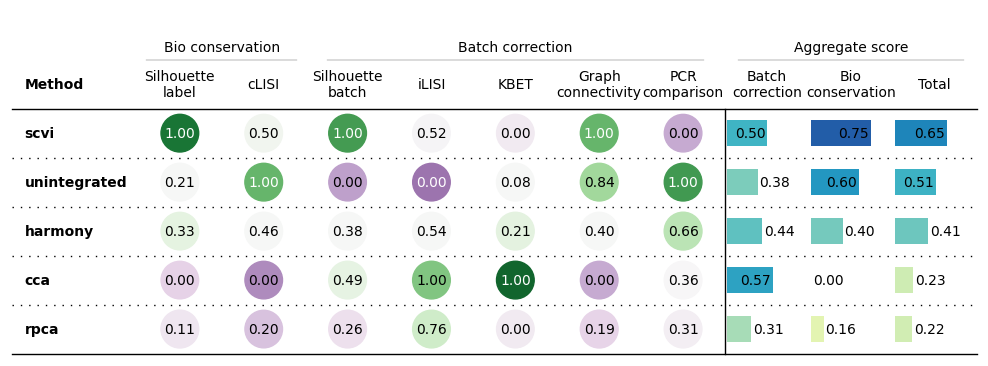

Saved to C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output\benchmark_results_table.png


In [50]:
import matplotlib.pyplot as plt

# 1. Generate the plottable Table object
table = bm.plot_results_table()

# 2. Access the underlying matplotlib figure and save it!
table.figure.savefig(
    output_dir / "benchmark_results_table.png", 
    dpi=600, 
    bbox_inches='tight', 
    facecolor='white'
)

# 3. Show it (if you are in a Jupyter Notebook)
plt.show()

print(f"Saved to {output_dir / 'benchmark_results_table.png'}")

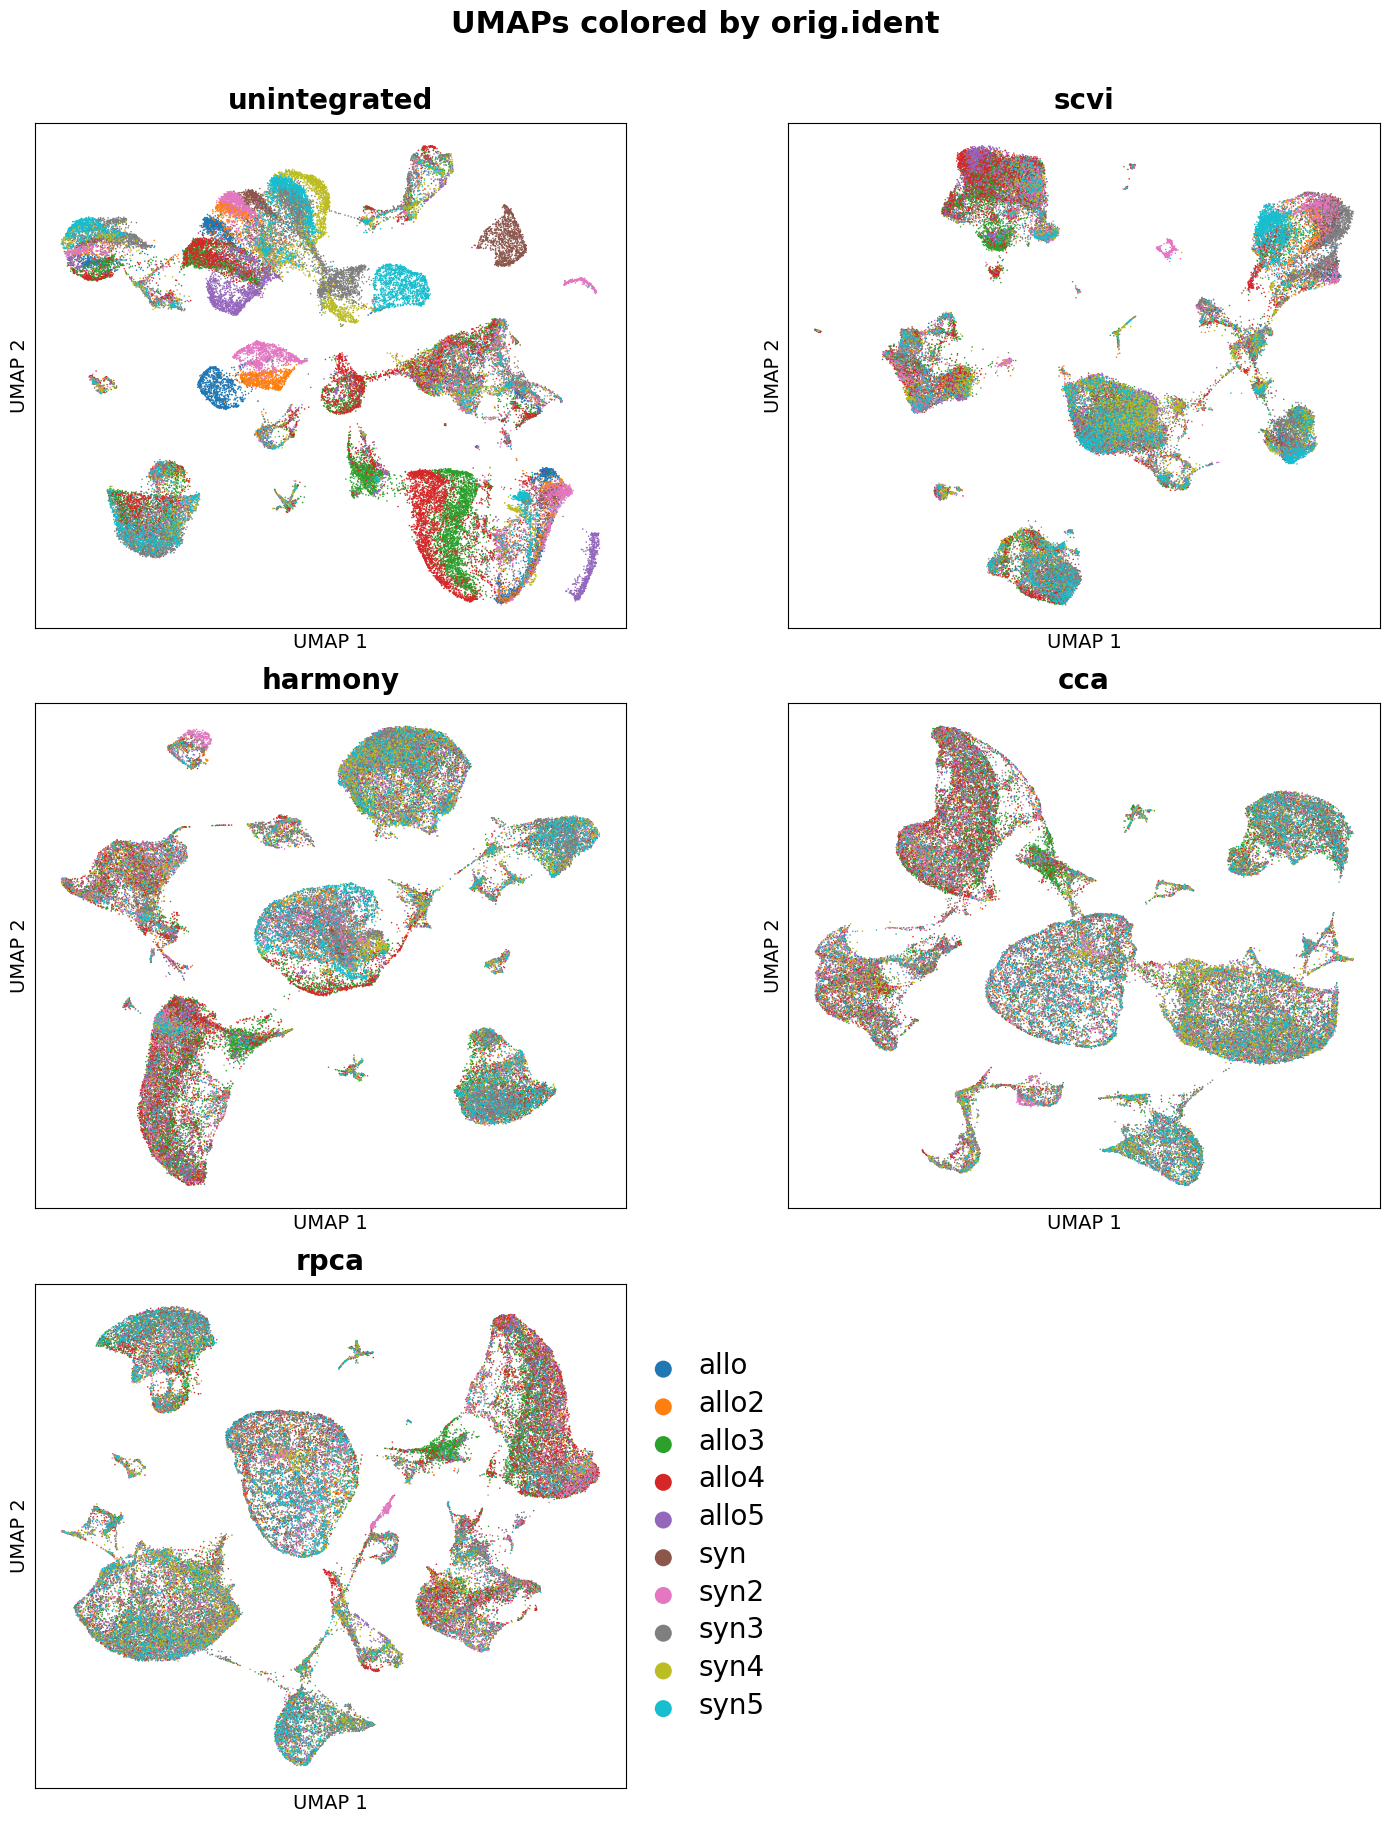

Saved to C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output\benchmark_umaps_grid.png


In [57]:
umap_order = ["unintegrated", "scvi", "harmony", "cca", "rpca"]
n_cols_grid = 2
n_rows_grid = int(np.ceil(len(umap_order) / n_cols_grid))  # 3 rows

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, 18))
axes_flat = axes.flatten()

for i, method in enumerate(umap_order):
    ax = axes_flat[i]
    umap_key = f"X_umap_{method}"

    if umap_key not in adata.obsm:
        ax.set_title(f'{method}\n(no UMAP found)', fontsize=16)
        ax.axis('off')
        continue

    adata.obsm["X_umap_plot"] = adata.obsm[umap_key]

    is_last = (i == len(umap_order) - 1)

    sc.pl.scatter(
        adata,
        basis='umap_plot',
        color=COLOR_BY,
        title=method,
        frameon=True,
        show=False,
        legend_loc='right margin' if is_last else 'none',
        legend_fontsize=14 if is_last else 0,
        ax=ax,
        size=5,
    )

    ax.set_title(method, fontsize=20, fontweight='bold', pad=10)
    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    ax.tick_params(labelsize=11)

# Hide empty subplot (last row, right column)
for j in range(len(umap_order), len(axes_flat)):
    axes_flat[j].axis('off')

if "X_umap_plot" in adata.obsm:
    del adata.obsm["X_umap_plot"]

# Make legend dots and text bigger on the last panel
last_ax = axes_flat[len(umap_order) - 1]
legend = last_ax.get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(20)
    for handle in legend.legend_handles:
        handle.set_sizes([600])

plt.suptitle(f'UMAPs colored by {COLOR_BY}', fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(output_dir / "benchmark_umaps_grid.png", dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to {output_dir / 'benchmark_umaps_grid.png'}")

In [58]:
combined_file = output_dir / "combined_all_methods.h5ad"
adata.write_h5ad(combined_file)
size_mb = combined_file.stat().st_size / (1024 * 1024)
print(f"Saved combined adata to {combined_file} ({size_mb:.1f} MB)")

print(f"\n{'='*60}")
print("All done!")
print(f"{'='*60}")
print(f"\nOutput files:")
for f in sorted(output_dir.glob("benchmark_*")):
    print(f"  {f.name}  ({f.stat().st_size / (1024*1024):.1f} MB)")
for f in sorted(output_dir.glob("*.h5ad")):
    print(f"  {f.name}  ({f.stat().st_size / (1024*1024):.1f} MB)")

Saved combined adata to C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output\combined_all_methods.h5ad (1853.2 MB)

All done!

Output files:
  benchmark_aggregate_3panel.png  (0.1 MB)
  benchmark_results.csv  (0.0 MB)
  benchmark_results_full.csv  (0.0 MB)
  benchmark_results_table.png  (0.5 MB)
  benchmark_tradeoff.png  (0.0 MB)
  benchmark_umaps_grid.png  (16.9 MB)
  cca.h5ad  (1772.6 MB)
  combined_all_methods.h5ad  (1853.2 MB)
  harmony.h5ad  (1773.0 MB)
  rpca.h5ad  (1772.4 MB)
  scvi.h5ad  (1767.7 MB)
  unintegrated.h5ad  (1750.0 MB)


In [ ]:
#optionl to reload everything without re-benchmarking
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import scanpy as sc

output_dir = Path(r"C:\Users\aabassetc2\Documents\github\benchmark-integration\data\output")

# Reload benchmark object
with open(output_dir / "benchmarker.pkl", 'rb') as f:
    bm = pickle.load(f)

# Show table
table = bm.plot_results_table()
plt.tight_layout()
plt.show()

# Reload combined adata (for UMAPs)
adata = sc.read_h5ad(output_dir / "combined_all_methods.h5ad")
print(adata)